# DenseNet Pretrained (ImageNet) + Class Weighting

- DenseNet121 with **ImageNet pretrained weights**
- **Phase 1** (10 epochs): backbone frozen, only classifier head trains
- **Phase 2** (10 epochs): full model unfrozen, fine-tuned at lower LR
- pos_weight in BCEWithLogitsLoss
- Adam optimizer
- learns good features from small dataset

### 1. Import libraries

In [ ]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.densenet_pretrained_weighted import DenseNetPretrainedWeighted
from src.training.trainer import train_one_epoch, validate_one_epoch

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score
)

os.chdir(ROOT)
print(Path.cwd())

### 2. Use Cuda else MPS

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

CUDA available: True
Using device: cuda


### 3. Load Dataset

Backbone frozen on init — only classifier head trains in phase 1.

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df   = pd.read_csv('data/splits/train.csv')
num_neg    = (train_df['label'] == 0).sum()
num_pos    = (train_df['label'] == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos]).to(device)
print(f'Non-Melanoma: {num_neg} | Melanoma: {num_pos} | pos_weight: {pos_weight.item():.3f}')

# freeze_features=True → backbone frozen for phase 1
model     = DenseNetPretrainedWeighted(freeze_features=True).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Non-Melanoma: 779 | Melanoma: 4693 | pos_weight: 0.166


c:\Users\lydia\Desktop\SUTD\50.039-Deep-Learning\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lydia\Desktop\SUTD\50.039-Deep-Learning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### 4. Phase 1 — Train classifier head only (Backbone Frozen)

In [5]:
# Only pass trainable params to optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)

epochs_phase1 = 10

train_losses, val_losses         = [], []
train_accuracies, val_accuracies = [], []
train_recalls, val_recalls       = [], []
train_f2s, val_f2s               = [], []
phase_labels                     = []

print('--- Phase 1: frozen backbone ---')
for epoch in range(epochs_phase1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])
    phase_labels.append('frozen')

    print(
        f"[Frozen] Epoch [{epoch+1}/{epochs_phase1}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, "s
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

--- Phase 1: frozen backbone ---
[Frozen] Epoch [1/10] | Train Loss: 0.1015, Acc: 0.8554, Recall: 0.0013, F2: 0.0016 | Val Loss: 0.0848, Acc: 0.8576, Recall: 0.0000, F2: 0.0000
[Frozen] Epoch [2/10] | Train Loss: 0.0823, Acc: 0.8591, Recall: 0.0103, F2: 0.0128 | Val Loss: 0.0800, Acc: 0.8576, Recall: 0.0000, F2: 0.0000
[Frozen] Epoch [3/10] | Train Loss: 0.0783, Acc: 0.8596, Recall: 0.0141, F2: 0.0176 | Val Loss: 0.0807, Acc: 0.8636, Recall: 0.0479, F2: 0.0591
[Frozen] Epoch [4/10] | Train Loss: 0.0794, Acc: 0.8589, Recall: 0.0141, F2: 0.0176 | Val Loss: 0.0780, Acc: 0.8585, Recall: 0.0060, F2: 0.0075
[Frozen] Epoch [5/10] | Train Loss: 0.0784, Acc: 0.8596, Recall: 0.0167, F2: 0.0208 | Val Loss: 0.0771, Acc: 0.8593, Recall: 0.0120, F2: 0.0149
[Frozen] Epoch [6/10] | Train Loss: 0.0753, Acc: 0.8640, Recall: 0.0501, F2: 0.0617 | Val Loss: 0.0760, Acc: 0.8636, Recall: 0.0419, F2: 0.0519
[Frozen] Epoch [7/10] | Train Loss: 0.0756, Acc: 0.8628, Recall: 0.0398, F2: 0.0492 | Val Loss: 0.0780,

### 5. Phase 2 — Unfreeze Backbone and fine-tune 

In [6]:
# Unfreeze all backbone layers
for param in model.model.features.parameters():
    param.requires_grad = True

# Lower LR to avoid overwriting pretrained weights
optimizer = optim.Adam(model.parameters(), lr=1e-5)

epochs_phase2 = 10

print('--- Phase 2: full fine-tune ---')
for epoch in range(epochs_phase2):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])
    phase_labels.append('unfrozen')

    print(
        f"[Unfrozen] Epoch [{epoch+1}/{epochs_phase2}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

--- Phase 2: full fine-tune ---
[Unfrozen] Epoch [1/10] | Train Loss: 0.0694, Acc: 0.8692, Recall: 0.0847, F2: 0.1036 | Val Loss: 0.0734, Acc: 0.8730, Recall: 0.1198, F2: 0.1449
[Unfrozen] Epoch [2/10] | Train Loss: 0.0653, Acc: 0.8755, Recall: 0.1297, F2: 0.1568 | Val Loss: 0.0710, Acc: 0.8806, Recall: 0.1737, F2: 0.2074
[Unfrozen] Epoch [3/10] | Train Loss: 0.0605, Acc: 0.8823, Recall: 0.1823, F2: 0.2175 | Val Loss: 0.0670, Acc: 0.8883, Recall: 0.2216, F2: 0.2620
[Unfrozen] Epoch [4/10] | Train Loss: 0.0548, Acc: 0.8889, Recall: 0.2285, F2: 0.2696 | Val Loss: 0.0663, Acc: 0.8909, Recall: 0.2395, F2: 0.2821
[Unfrozen] Epoch [5/10] | Train Loss: 0.0509, Acc: 0.8927, Recall: 0.2529, F2: 0.2969 | Val Loss: 0.0683, Acc: 0.8832, Recall: 0.1856, F2: 0.2214
[Unfrozen] Epoch [6/10] | Train Loss: 0.0473, Acc: 0.9013, Recall: 0.3119, F2: 0.3613 | Val Loss: 0.0675, Acc: 0.8917, Recall: 0.2395, F2: 0.2825
[Unfrozen] Epoch [7/10] | Train Loss: 0.0446, Acc: 0.9031, Recall: 0.3299, F2: 0.3801 | Val 

### 5. Plot loss and accuracy curves

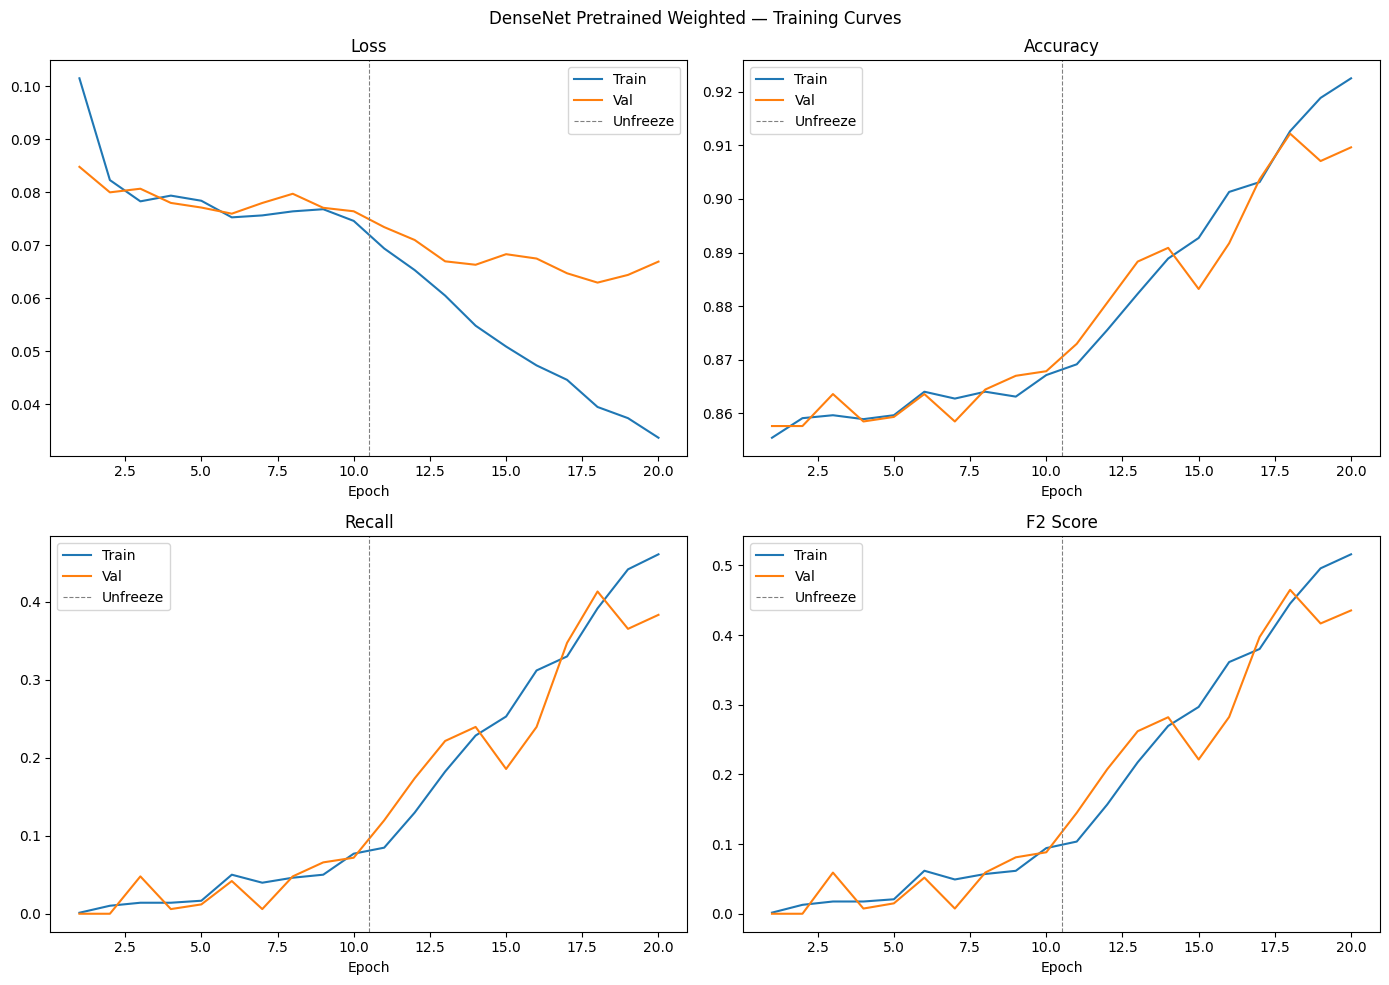

In [7]:
total_epochs = epochs_phase1 + epochs_phase2
ep           = range(1, total_epochs + 1)
split_at     = epochs_phase1 + 0.5   # vertical line between phases

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, train_vals, val_vals, title in zip(
    axes.flatten(),
    [train_losses, train_accuracies, train_recalls, train_f2s],
    [val_losses,   val_accuracies,   val_recalls,   val_f2s],
    ['Loss', 'Accuracy', 'Recall', 'F2 Score']
):
    ax.plot(ep, train_vals, label='Train')
    ax.plot(ep, val_vals,   label='Val')
    ax.axvline(x=split_at, color='gray', linestyle='--', linewidth=0.8, label='Unfreeze')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()

plt.suptitle('DenseNet Pretrained Weighted — Training Curves')
plt.tight_layout()
plt.show()

### 7. Evaluate model

In [8]:
model.eval()

all_labels = []
all_probs  = []
all_preds  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs >= 0.5)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)
print(classification_report(all_labels, all_preds, digits=4))
print(f'AUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}')

Confusion Matrix:
[[1001    5]
 [ 110   57]]
              precision    recall  f1-score   support

           0     0.9010    0.9950    0.9457      1006
           1     0.9194    0.3413    0.4978       167

    accuracy                         0.9020      1173
   macro avg     0.9102    0.6682    0.7217      1173
weighted avg     0.9036    0.9020    0.8819      1173

AUC-ROC: 0.9449


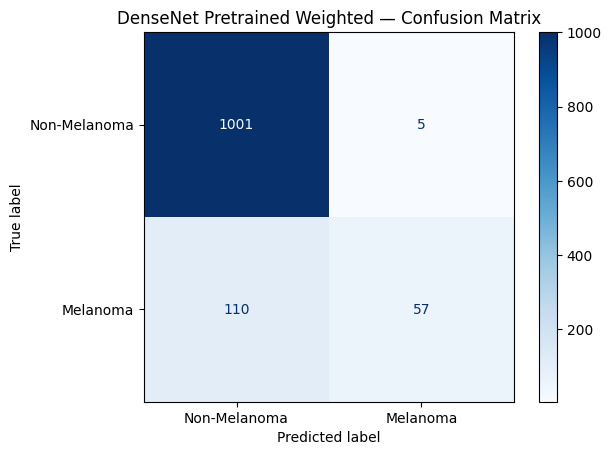

In [9]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('DenseNet Pretrained Weighted — Confusion Matrix')
plt.show()